In [34]:
import os
import random
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from tqdm import tqdm
from PIL import Image
from collections import Counter
from multiprocessing import Pool, cpu_count

import torch
from torchvision import transforms
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')

In [37]:
INPUT_DIR  = "/kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images"
OUTPUT_DIR = "/kaggle/working/preprocessed"
META_PATH  = "/kaggle/working/meta.json"
CSV_PATH   = "/kaggle/working/split.csv"

IMAGE_SIZE  = 224
USE_RATIO   = 1.0
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = sorted(os.listdir(INPUT_DIR))
NUM_CLASSES = len(CLASS_NAMES)
SHORT_NAMES = [c.replace('Demented', '').replace('Non', 'Non-D') for c in CLASS_NAMES]
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (4): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [38]:
all_paths  = []
all_labels = []
class_sizes = {}

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(INPUT_DIR, cls)
    files   = [f for f in os.listdir(cls_dir)
               if os.path.isfile(os.path.join(cls_dir, f))]
    random.shuffle(files)
    n = int(len(files) * USE_RATIO)
    class_sizes[cls] = n
    for fname in files[:n]:
        all_paths.append(os.path.join(cls_dir, fname))
        all_labels.append(idx)

print(f"Total images: {len(all_paths)}")

Total images: 44000


In [39]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}:", {CLASS_NAMES[k]: v for k, v in sorted(c.items())})

Train: 35200 | Val: 4400 | Test: 4400
  train: {'MildDemented': 8000, 'ModerateDemented': 8000, 'NonDemented': 10240, 'VeryMildDemented': 8960}
  val: {'MildDemented': 1000, 'ModerateDemented': 1000, 'NonDemented': 1280, 'VeryMildDemented': 1120}
  test: {'MildDemented': 1000, 'ModerateDemented': 1000, 'NonDemented': 1280, 'VeryMildDemented': 1120}


In [40]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

to_tensor = transforms.ToTensor()


def save_split(paths, labels, split_name):
    records = []
    for path, label in tqdm(zip(paths, labels), total=len(paths),
                            desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, split_name, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir,
                    os.path.splitext(os.path.basename(path))[0] + ".pt")
        img    = Image.open(path).convert("L")
        img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = to_tensor(img)
        tensor = (tensor * 255).byte()
        tensor = tensor.repeat(3, 1, 1)
        torch.save(tensor, out_path)
        records.append({'path': out_path, 'label': label,
                        'class': cls_name, 'split': split_name})
    return records


records  = save_split(train_paths, train_labels, "train")
records += save_split(val_paths,   val_labels,   "val")
records += save_split(test_paths,  test_labels,  "test")
print(f"\nTotal tensors saved: {len(records)}")

Saving test: 100%|██████████| 4400/4400 [00:18<00:00, 237.49it/s]


Total tensors saved: 44000


In [42]:
df_records = pd.DataFrame(records)
df_records.to_csv(CSV_PATH, index=False)
print(f"Split manifest saved to {CSV_PATH}")
print(df_records.groupby(['split', 'class']).size().unstack().to_string())

Split manifest saved to /kaggle/working/split.csv
class  MildDemented  ModerateDemented  NonDemented  VeryMildDemented
split                                                               
test           1000              1000         1280              1120
train          8000              8000        10240              8960
val            1000              1000         1280              1120


In [43]:
meta = {
    'class_names':   CLASS_NAMES,
    'num_classes':   NUM_CLASSES,
    'image_size':    IMAGE_SIZE,
    'use_ratio':     USE_RATIO,
    'train_ratio':   TRAIN_RATIO,
    'val_ratio':     VAL_RATIO,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std':  IMAGENET_STD,
    'tensor_dtype':  'uint8',
    'tensor_shape':  [3, IMAGE_SIZE, IMAGE_SIZE],
    'note':          'Convert: tensor.float() / 255.0 then Normalize(mean, std)',
    'seed':          SEED,
    'output_dir':    OUTPUT_DIR,
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"Metadata saved to {META_PATH}")

Metadata saved to /kaggle/working/meta.json


In [44]:
print("=== Tensor check ===")
for split_name in ['train', 'val', 'test']:
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    first_cls  = sorted(os.listdir(split_dir))[0]
    first_file = os.listdir(os.path.join(split_dir, first_cls))[0]
    t = torch.load(os.path.join(split_dir, first_cls, first_file), weights_only=True)
    print(f"  {split_name}: shape={tuple(t.shape)}  dtype={t.dtype}  "
          f"min={t.min().item()}  max={t.max().item()}")

=== Tensor check ===
  train: shape=(3, 224, 224)  dtype=torch.uint8  min=0  max=255
  val: shape=(3, 224, 224)  dtype=torch.uint8  min=0  max=209
  test: shape=(3, 224, 224)  dtype=torch.uint8  min=14  max=255


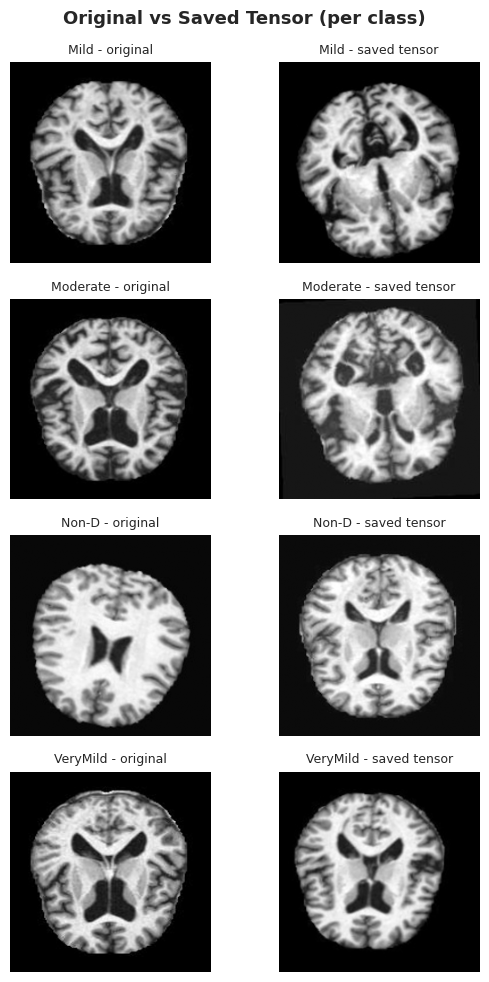

In [46]:
fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(6, NUM_CLASSES * 2.5))
fig.suptitle('Original vs Saved Tensor (per class)', fontsize=13, fontweight='bold')

for row, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    orig_path = random.choice([p for p, l in zip(train_paths, train_labels) if l == label])
    orig_img  = Image.open(orig_path).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE))
    cls_dir   = os.path.join(OUTPUT_DIR, 'train', cls)
    pt_path   = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    tensor    = torch.load(pt_path, weights_only=True)
    axes[row][0].imshow(orig_img, cmap='gray')
    axes[row][0].set_title(f'{SHORT_NAMES[row]} - original', fontsize=9)
    axes[row][0].axis('off')
    axes[row][1].imshow(tensor[0].numpy(), cmap='gray')
    axes[row][1].set_title(f'{SHORT_NAMES[row]} - saved tensor', fontsize=9)
    axes[row][1].axis('off')

plt.tight_layout()
plt.show()

In [47]:
summary = df_records.groupby(['split', 'class']).size().unstack(fill_value=0)
summary['TOTAL'] = summary.sum(axis=1)
print("\n=== Final split summary ===")
print(summary.to_string())
print(f"\nPreprocessing complete. All files in {OUTPUT_DIR}")


=== Final split summary ===
class  MildDemented  ModerateDemented  NonDemented  VeryMildDemented  TOTAL
split                                                                      
test           1000              1000         1280              1120   4400
train          8000              8000        10240              8960  35200
val            1000              1000         1280              1120   4400

Preprocessing complete. All files in /kaggle/working/preprocessed
